# XGBoost — Student Test Score Prediction
MSE 546 Final Project — Group 3

XGBoost regressor to predict student exam scores.

## 1. Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

## 2. Load Data

In [23]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
sample_sub = pd.read_csv('../data/sample_submission.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
train_df.head()

Train shape: (630000, 13)
Test shape: (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


## 3. Quick EDA

In [24]:
print(train_df.info())
print('\n--- Missing Values ---')
print(train_df.isnull().sum())
print('\n--- Target Stats ---')
print(train_df['exam_score'].describe())

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  str    
 3   course            630000 non-null  str    
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  str    
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  str    
 9   study_method      630000 non-null  str    
 10  facility_rating   630000 non-null  str    
 11  exam_difficulty   630000 non-null  str    
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 62.5 MB
None

--- Missing Values ---
id                  0
age                 0
gender              0
course              0
stud

## 4. Preprocessing

Encode categorical features using Label Encoding. We fit encoders on the combined train+test data to avoid unseen labels at prediction time.

In [25]:
# Identify categorical columns
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality',
                    'study_method', 'facility_rating', 'exam_difficulty']

# Label encode each categorical column (fit on combined data)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

print('Encoding complete.')
train_df.head()

Encoding complete.


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,0,1,7.91,98.8,0,4.9,0,3,1,0,78.3
1,1,18,2,6,4.95,94.8,1,4.7,2,4,2,2,46.7
2,2,20,0,1,4.68,92.6,1,5.8,2,0,0,2,99.0
3,3,19,1,1,2.00,49.5,1,8.3,0,1,0,2,63.9
4,4,23,1,5,7.65,86.9,1,9.6,1,4,0,0,100.0


## 5. Prepare Features and Target

In [26]:
# Features (drop id and target)
feature_cols = [c for c in train_df.columns if c not in ['id', 'exam_score']]

X = train_df[feature_cols]
y = train_df['exam_score']
X_test = test_df[feature_cols]

print(f'Features: {feature_cols}')
print(f'X shape: {X.shape}, y shape: {y.shape}, X_test shape: {X_test.shape}')

Features: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']
X shape: (630000, 11), y shape: (630000,), X_test shape: (270000, 11)


## 6. Train/Validation Split

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}, Validation: {X_val.shape}')

Train: (504000, 11), Validation: (126000, 11)


## 7. Train XGBoost Model

In [28]:
model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=50,
    verbosity=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-rmse:18.20625
[100]	validation_0-rmse:8.83848
[200]	validation_0-rmse:8.78713
[300]	validation_0-rmse:8.77500
[400]	validation_0-rmse:8.76391
[500]	validation_0-rmse:8.75716
[600]	validation_0-rmse:8.75243
[700]	validation_0-rmse:8.74912
[800]	validation_0-rmse:8.74572
[900]	validation_0-rmse:8.74398
[999]	validation_0-rmse:8.74230

Best iteration: 999


## 8. Evaluate on Validation Set

In [29]:
y_pred_val = model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2 = r2_score(y_val, y_pred_val)

print('=== Validation Results ===')
print(f'MAE:  {mae}')
print(f'RMSE: {rmse}')
print(f'R²:   {r2}')

=== Validation Results ===
MAE:  6.967385624984863
RMSE: 8.742304680647909
R²:   0.7851019193524618


## 9. Actual vs Predicted — Scatter Plot and Error Distribution

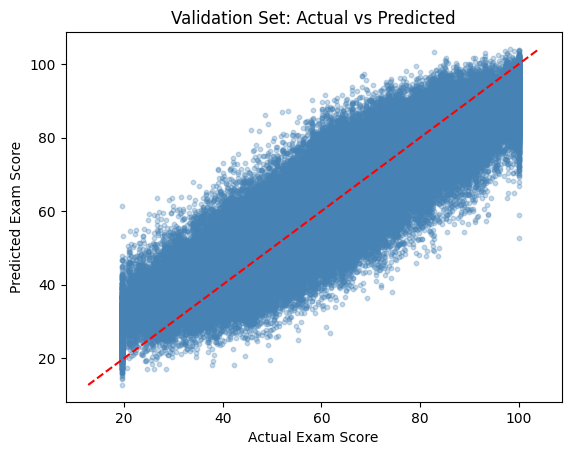

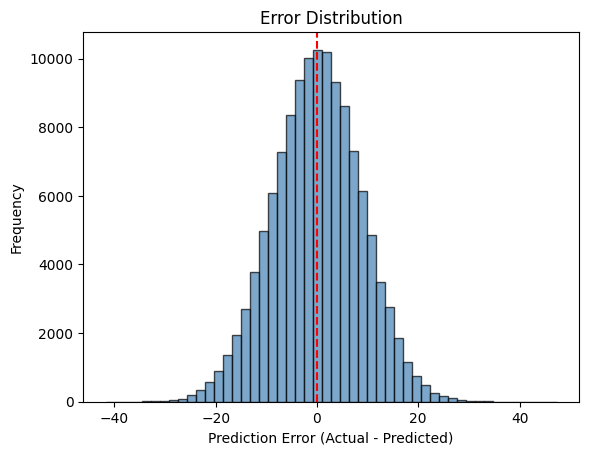

In [30]:
#scatter plot
plt.scatter(y_val, y_pred_val, alpha=0.3, s=10, color='steelblue', label='Predictions')
min_val = min(y_val.min(), y_pred_val.min())
max_val = max(y_val.max(), y_pred_val.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title(f'Validation Set: Actual vs Predicted')
plt.show()

#error distribution graph
errors = y_val - y_pred_val
plt.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.show()

## 10. Feature Importance

In [31]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.to_string(index=False))

         feature  importance
     study_hours    0.518459
   sleep_quality    0.162836
 facility_rating    0.097599
    study_method    0.094626
class_attendance    0.088233
     sleep_hours    0.025107
             age    0.002906
          gender    0.002736
          course    0.002705
 exam_difficulty    0.002412
 internet_access    0.002381


## 11. Generate Submission

In [32]:
# Predict on test set
test_predictions = model.predict(X_test)

# Create submission DataFrame
submission = pd.DataFrame({
    'id': test_df['id'],
    'exam_score': test_predictions
})

# Save to submission folder
import os
os.makedirs('../submission', exist_ok=True)
submission.to_csv('../submission/xgboost_submission.csv', index=False)

print(f'Submission shape: {submission.shape}')
print(f'Saved to ../submission/xgboost_submission.csv')
submission.head()

Submission shape: (270000, 2)
Saved to ../submission/xgboost_submission.csv


,id,exam_score
0,630000,71.507805
1,630001,70.925919
2,630002,87.922668
3,630003,56.221386
4,630004,48.204670
